In [55]:
import pandas as pd
import importlib
import neuropixel_data_schema
import recording_report

importlib.reload(neuropixel_data_schema)
importlib.reload(recording_report)

Connected: True
Schema ready: neuropixel_data_pipeline


<module 'recording_report' from '/Users/zosiasus/Documents/databases_practice/recording_report.py'>

In [56]:
from neuropixel_data_schema import Trial
print(Trial.heading.names)

['recording_id', 'trial_idx', 'trial_id', 'trial_name', 'trial_type', 'sol_direction', 'idx_sol_direction', 'idx_sol_on', 'trial_length', 'bin_size_sec', 'n_time_bins']


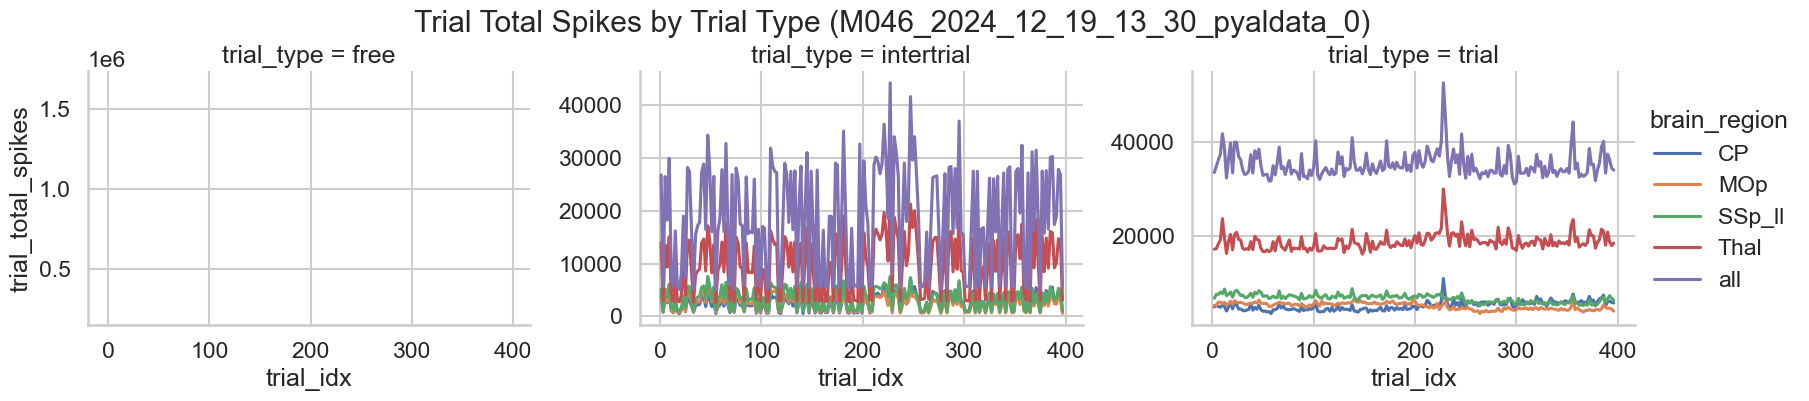

In [57]:
recording_report.plot_trial_totals(
    recording_id="M046_2024_12_19_13_30_pyaldata_0",
    include_all=True,
    by_trial_type=True,
)

### What recordings are in database?

In [58]:
meta = recording_metadata()
display(meta)

,recording_id,mat_file_path,animal,session_label,session_datetime,part_index,file_size_bytes,n_trials
0,M046_2024_12_19_13_30_pyaldata_0,/Users/zosiasus/Documents/M046/M046_2024_12_19...,M046,2024_12_19_13_30,2024-12-19 13:30:00,0,1970048264,398
1,M046_2024_12_19_13_30_pyaldata_1,/Users/zosiasus/Documents/M046/M046_2024_12_19...,M046,2024_12_19_13_30,2024-12-19 13:30:00,1,1877218192,398


### Recording to look at

In [59]:
recording_id = "M046_2024_12_19_13_30_pyaldata_0"

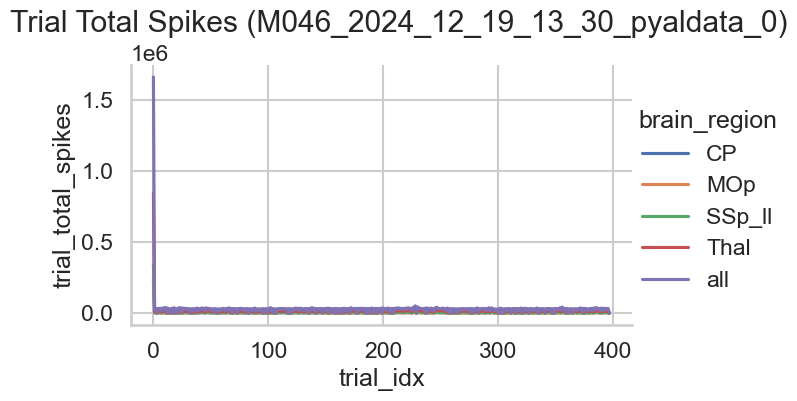

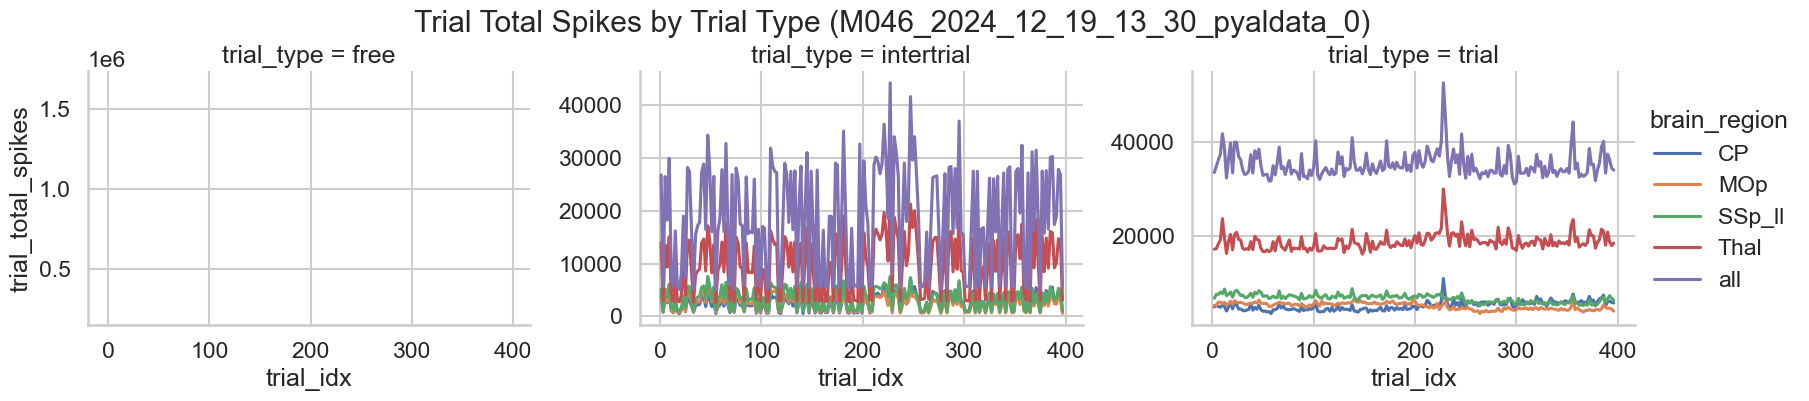

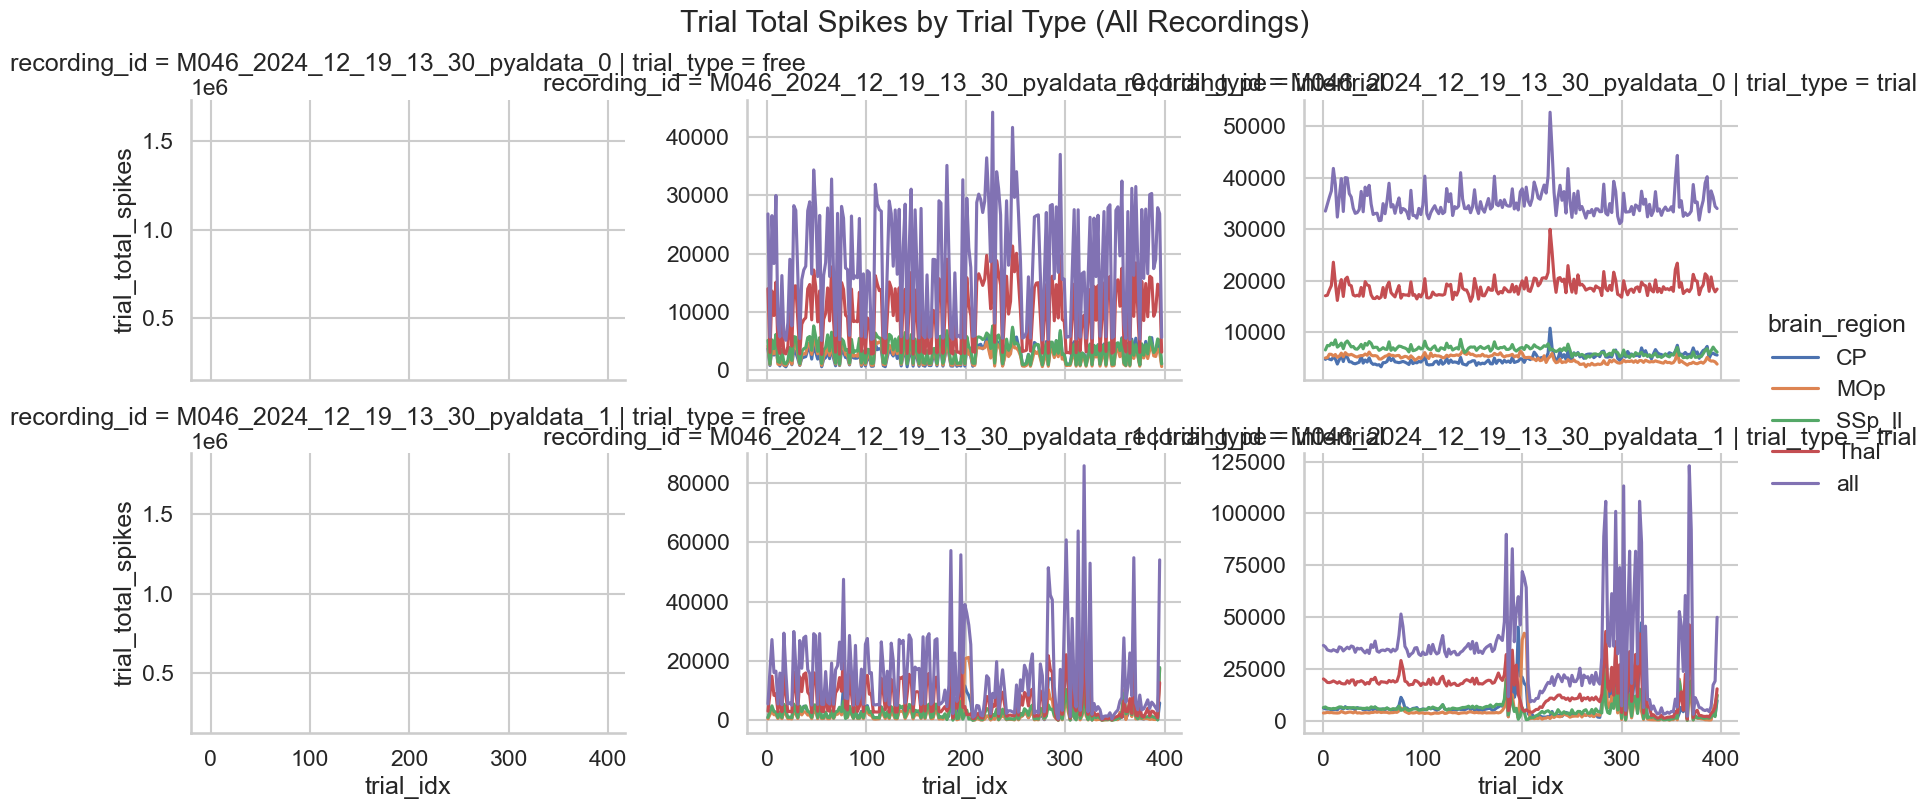

In [60]:
# one recording
plot_trial_totals(recording_id="M046_2024_12_19_13_30_pyaldata_0", include_all=True, by_trial_type=False)

# one recording split by trial type
plot_trial_totals(recording_id="M046_2024_12_19_13_30_pyaldata_0", include_all=True, by_trial_type=True)

# all recordings split by trial type
plot_trial_totals(recording_id=None, include_all=True, by_trial_type=True)

### Build recording report tables

In [61]:
report = build_recording_report(recording_id, include_all=True, top_n=10)

display(report["recording_metadata"])
display(report["trial_counts"])
display(report["unit_counts_by_region"])
display(report["spike_stats_by_region"])
display(report["zero_fraction_by_region"])

,recording_id,mat_file_path,animal,session_label,session_datetime,part_index,file_size_bytes,n_trials
0,M046_2024_12_19_13_30_pyaldata_0,/Users/zosiasus/Documents/M046/M046_2024_12_19...,M046,2024_12_19_13_30,2024-12-19 13:30:00,0,1970048264,398


,recording_id,n_trials_loaded
0,M046_2024_12_19_13_30_pyaldata_0,398


,recording_id,brain_region,n_units
0,M046_2024_12_19_13_30_pyaldata_0,CP,455
1,M046_2024_12_19_13_30_pyaldata_0,MOp,281
2,M046_2024_12_19_13_30_pyaldata_0,SSp_ll,198
3,M046_2024_12_19_13_30_pyaldata_0,Thal,184
4,M046_2024_12_19_13_30_pyaldata_0,all,19


,recording_id,brain_region,mean_spikes,median_spikes,std_spikes
0,M046_2024_12_19_13_30_pyaldata_0,CP,9.630742,1.0,63.441589
1,M046_2024_12_19_13_30_pyaldata_0,MOp,15.574805,1.0,116.037365
2,M046_2024_12_19_13_30_pyaldata_0,SSp_ll,29.468238,3.0,202.965068
3,M046_2024_12_19_13_30_pyaldata_0,Thal,88.791266,44.0,340.450974
4,M046_2024_12_19_13_30_pyaldata_0,all,27.666200,3.0,179.382646


,recording_id,brain_region,zero_fraction
0,M046_2024_12_19_13_30_pyaldata_0,CP,0.443332
1,M046_2024_12_19_13_30_pyaldata_0,MOp,0.468812
2,M046_2024_12_19_13_30_pyaldata_0,SSp_ll,0.346886
3,M046_2024_12_19_13_30_pyaldata_0,Thal,0.047029
4,M046_2024_12_19_13_30_pyaldata_0,all,0.367432


In [62]:
from neuropixel_data_schema import Unit, AllUnitMap, AllTrialSpikeCount

print("Raw Unit all count:", len((Unit & {'recording_id': recording_id}) & 'brain_region="all"'))
print("Computed AllUnitMap count:", len(AllUnitMap & {'recording_id': recording_id}))
print("Computed all spike rows:", len(AllTrialSpikeCount & {'recording_id': recording_id}))

Raw Unit all count: 19
Computed AllUnitMap count: 1118
Computed all spike rows: 444964


### Neuron unit summary stats

In [63]:
display(report["top_units"].head(30))
display(report["bottom_units"].head(30))

,recording_id,brain_region,unit_idx,avg_spikes_per_trial,active_fraction
0,M046_2024_12_19_13_30_pyaldata_0,all,1050,423.072864,1.000000
1,M046_2024_12_19_13_30_pyaldata_0,Thal,116,423.072864,1.000000
2,M046_2024_12_19_13_30_pyaldata_0,all,990,386.080402,1.000000
3,M046_2024_12_19_13_30_pyaldata_0,Thal,56,386.080402,1.000000
4,M046_2024_12_19_13_30_pyaldata_0,all,813,355.482412,1.000000
5,M046_2024_12_19_13_30_pyaldata_0,SSp_ll,77,355.482412,1.000000
6,M046_2024_12_19_13_30_pyaldata_0,Thal,119,334.748744,1.000000
7,M046_2024_12_19_13_30_pyaldata_0,all,1053,334.748744,1.000000
8,M046_2024_12_19_13_30_pyaldata_0,MOp,253,312.625628,1.000000
9,M046_2024_12_19_13_30_pyaldata_0,all,708,312.625628,1.000000


,recording_id,brain_region,unit_idx,avg_spikes_per_trial,active_fraction
0,M046_2024_12_19_13_30_pyaldata_0,all,844,0.0,0.0
1,M046_2024_12_19_13_30_pyaldata_0,CP,408,0.0,0.0
2,M046_2024_12_19_13_30_pyaldata_0,CP,409,0.0,0.0
3,M046_2024_12_19_13_30_pyaldata_0,CP,442,0.0,0.0
4,M046_2024_12_19_13_30_pyaldata_0,MOp,4,0.0,0.0
5,M046_2024_12_19_13_30_pyaldata_0,MOp,21,0.0,0.0
6,M046_2024_12_19_13_30_pyaldata_0,MOp,38,0.0,0.0
7,M046_2024_12_19_13_30_pyaldata_0,MOp,58,0.0,0.0
8,M046_2024_12_19_13_30_pyaldata_0,MOp,60,0.0,0.0
9,M046_2024_12_19_13_30_pyaldata_0,MOp,85,0.0,0.0


### Plot - trial total spike counts

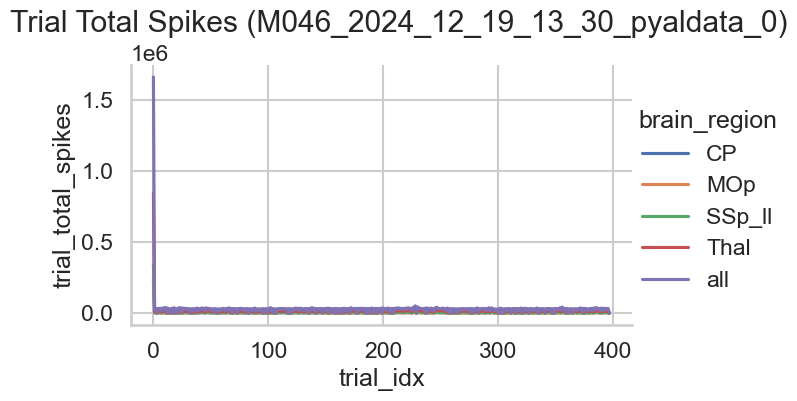

In [64]:
plot_trial_totals(recording_id, include_all=True)

### Plot distributions

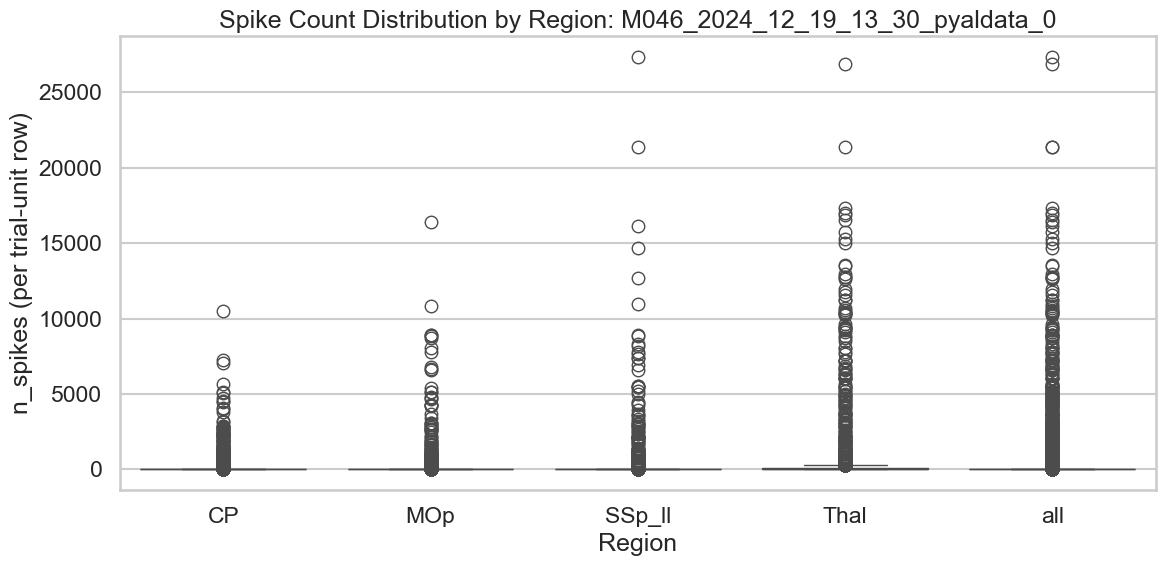

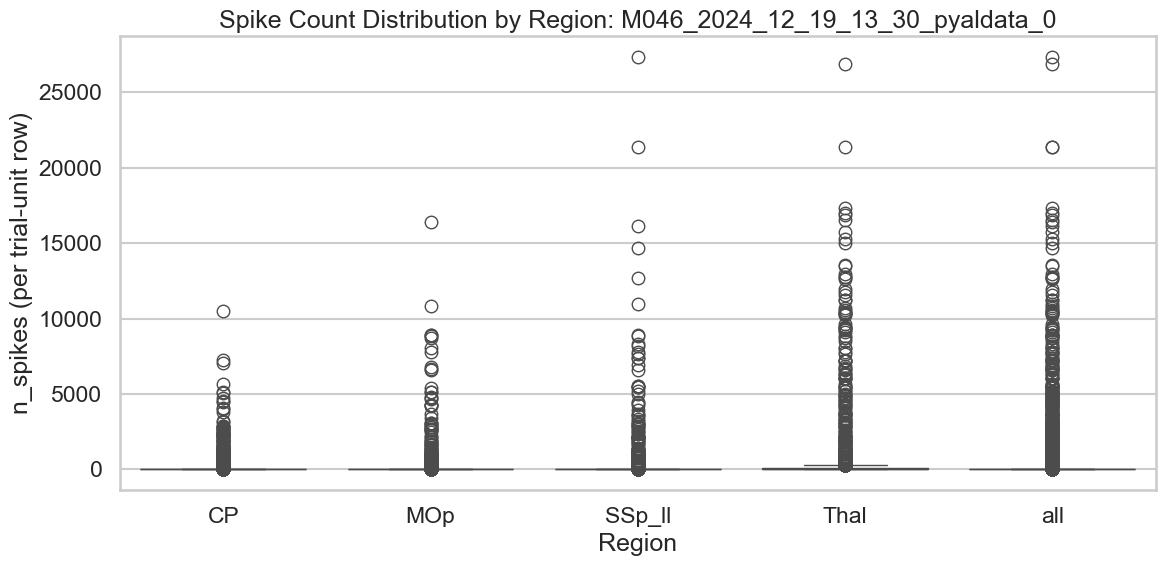

In [65]:
plot_spike_distributions(recording_id, include_all=True)

### Compare _0 and _1 recording files

In [66]:
consistency = part_consistency_summary(include_all=False)
display(consistency)

,animal,session_label,part_index,recording_id,brain_region,median_spikes,mean_spikes
0,M046,2024_12_19_13_30,0,M046_2024_12_19_13_30_pyaldata_0,CP,1.0,9.630742
4,M046,2024_12_19_13_30,1,M046_2024_12_19_13_30_pyaldata_1,CP,0.0,15.057949
1,M046,2024_12_19_13_30,0,M046_2024_12_19_13_30_pyaldata_0,MOp,1.0,15.574805
5,M046,2024_12_19_13_30,1,M046_2024_12_19_13_30_pyaldata_1,MOp,0.0,16.292682
2,M046,2024_12_19_13_30,0,M046_2024_12_19_13_30_pyaldata_0,SSp_ll,3.0,29.468238
6,M046,2024_12_19_13_30,1,M046_2024_12_19_13_30_pyaldata_1,SSp_ll,2.0,23.115273
3,M046,2024_12_19_13_30,0,M046_2024_12_19_13_30_pyaldata_0,Thal,44.0,88.791266
7,M046,2024_12_19_13_30,1,M046_2024_12_19_13_30_pyaldata_1,Thal,23.0,65.794653
